# DATASCI 503, Homework 7: Ensemble Methods and Decision Trees

This assignment covers classification trees, random forests, and gradient boosting classifiers.

---

**Problem 1 (ISLP Ch 8, Exercise 5):** Majority Vote vs Average Probability

Suppose we produce ten bootstrapped samples from a data set containing red and green classes. We then apply a classification tree to each bootstrapped sample and, for a specific value of X, produce 10 estimates of P(Class is Red|X): 0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, and 0.75.

There are two common ways to combine these results together into a single class prediction. One is the majority vote approach discussed in this chapter. The second approach is to classify based on the average probability. In this example, what is the final classification under each of these two approaches?

> **Majority vote:** classify each tree as Red if $\hat p(\text{Red}\mid X) > 0.5$. Here, 6 of the 10 probabilities exceed 0.5, so the majority vote predicts **Red**.

 > **Average probability:** average the probabilities:
$$(0.1+0.15+0.2+0.2+0.55+0.6+0.6+0.65+0.7+0.75)/10 = 4.5/10 = 0.45.$$
Since $0.45 < 0.5$, the average-probability approach predicts **Green**.

---

**Problem 2:** Gradient Boosting with Decision Stumps

Consider using gradient boosting to solve a regression problem. Assume that at each iteration, we fit the residuals using a "decision stump": a decision tree with exactly two leaf nodes. In this case, the final estimate of the regression function can be expressed in the form:

$$\hat{f}(X) = \sum_{j=1}^{p} \hat{f}_j(X_j)$$

**Question:** Explain why this is the case.

At each boosting iteration, the fitted weak learner is a decision stump, so it depends on only one predictor. Thus, for each $b$, there exists some $j(b) \in \{1,\dots,p\}$ such that
$$
h_b(X) = h_{b,j(b)}(X_{j(b)}).
$$

The boosted model is
$$
\hat f(X) = \sum_{b=1}^B \lambda h_b(X) = \sum_{b=1}^B \lambda h_{b,j(b)}(X_{j(b)}).
$$

We can regroup this sum by collecting all terms corresponding to the same predictor:
$$
\hat f(X) = \sum_{j=1}^p \left( \sum_{b:\, j(b)=j} \lambda h_{b,j}(X_j) \right).
$$

Defining
$$
\hat f_j(X_j) := \sum_{b:\, j(b)=j} \lambda h_{b,j}(X_j),
$$
we obtain
$$
\hat f(X) = \sum_{j=1}^p \hat f_j(X_j).
$$

---

**Problem 3:** Classification Tree Sketches

Create a sketch that illustrates the connection between a decision
tree and the partition of input space that is implied by that decision tree. You
can do this on paper (and scan it) or use a drawing program.

(a) Draw an example partition of a two-dimensional feature space that could
result from a tree with binary splits, with each feature defined on the
interval [−1, 1]. Include at least 5 regions

One valid example partition (with features on $[-1,1]$) is produced by these binary splits:

- Split 1 (root): $X_1 < 0.2$
- Split 2 (left side): $X_2 < -0.3$
- Split 3 (left & upper): $X_2 < 0.6$
- Split 4 (right side): $X_1 < 0.7$
- Split 5 (right & far-right): $X_2 < 0.0$

This creates **5+ rectangular regions**. I included a small plot in the next cell that draws these split lines and labels regions.

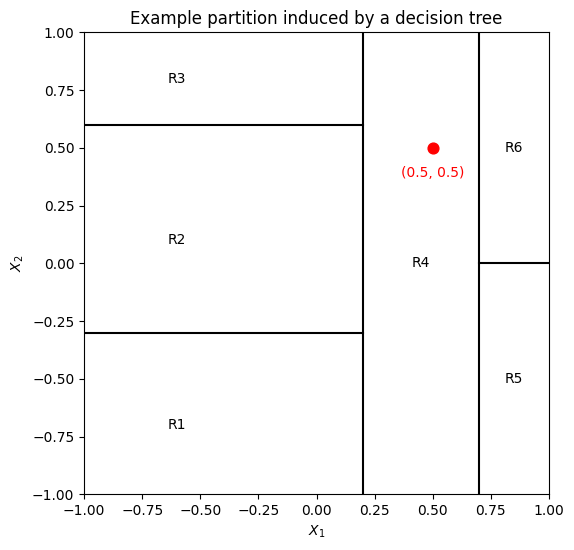

In [16]:
# Problem 3(a) sketch: example partition in [-1, 1]^2 with 6 regions
import matplotlib.pyplot as plt
import numpy as np

# Split thresholds (match the description in the text answer)
t1 = 0.2   # vertical split for X1
t2 = -0.3  # horizontal split (left side)
t3 = 0.6   # horizontal split (left side, upper)
t4 = 0.7   # vertical split (right side)
t5 = 0.0   # horizontal split (far-right)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

ax.set_xlabel(r"$X_1$")
ax.set_ylabel(r"$X_2$")
ax.set_title("Example partition induced by a decision tree")

# Draw split lines
ax.plot([t1, t1], [-1, 1], color="black")
ax.plot([t4, t4], [-1, 1], color="black")
ax.plot([-1, t1], [t2, t2], color="black")
ax.plot([-1, t1], [t3, t3], color="black")
ax.plot([t4, 1], [t5, t5], color="black")

# Label a few regions (approximate centers)
labels = [
    ("R1", -0.6, -0.7),
    ("R2", -0.6,  0.1),
    ("R3", -0.6,  0.8),
    ("R4",  0.45, 0),
    ("R5",  0.85,-0.5),
    ("R6",  0.85, 0.5),
 ]
for txt, x, y in labels:
    ax.text(x, y, txt, ha="center", va="center")

# Mark the point from part (c)
x_pt, y_pt = 0.5, 0.5
ax.scatter([x_pt], [y_pt], color="red", s=60)
ax.text(x_pt, y_pt - 0.08, "(0.5, 0.5)", color="red", ha="center", va="top")

plt.show()

(b) Draw a decision tree corresponding to the partition you drew, labeling
every tree branch. Show terminal nodes as rectangles and interior nodes
as circles. Do not include predictions at the terminal nodes, just the
branch labels (e.g. $X_1 < 0.5$).

A decision tree corresponding to the split rules described in (a) is:

- Root: $X_1 < 0.2$?
  - Yes (left): $X_2 < -0.3$?
    - Yes: **Region 1**
    - No: $X_2 < 0.6$?
      - Yes: **Region 2**
      - No: **Region 3**
  - No (right): $X_1 < 0.7$?
    - Yes: **Region 4**
    - No: $X_2 < 0.0$?
      - Yes: **Region 5**
      - No: **Region 6**

This matches the axis-aligned rectangles shown by the partition plot (each internal node is one axis-aligned split).

![Decision Tree](DecisionTree.png)

(c) Draw the path of a particular point, with $X_1 = X_2 = 0.5$, through your
tree and label the terminal node where it ends up. Mark this point in
your plot from part (a) as well.

For the point $(X_1,X_2)=(0.5,0.5)$:

- At root, $0.5 < 0.2$ is **false**, so go right.
- Next, $X_1 < 0.7$ is **true** (since $0.5<0.7$).
- Therefore the point ends in **Region 4** in the example tree above.

The plot cell (added after part (a)) marks this point as well.

## Crab Species Classification

The following problems use the crabs dataset, which contains five size-related measurements of two different species of crabs (blue and orange). There are 50 male and 50 female crabs of each species. We will classify species based on the predictor variables and evaluate errors using the misclassification rate.

---

**Problem 4:** Train-Test Split

Load the crabs dataset and perform a train-test split with the following specifications:
- Random state: 6789
- Training set size: 80% of the dataset
- Stratify the split according to both species and sex

This stratification ensures that approximately the same proportions of species/sex combinations appear in both the training and test datasets.

Store the results in `X_train`, `X_test`, `y_train`, and `y_test`. The features should include the five numerical measurements and sex (encoded as 0 for Female, 1 for Male). The target should be the species column.

In [ ]:
# Load the crabs dataset
crabs = pd.read_csv("data/crabs.csv", index_col=[0])
print(crabs.head(), "\n" ,crabs.columns)

# Encode sex as 0/1
crabs["sex_code"] = crabs["sex"].map({"F": 0, "M": 1})

# Target
y = crabs[["sp"]]

# Use only the five numeric measurements plus sex
X = crabs[["FL", "RW", "CL", "CW", "BD", "sex_code"]]

# Stratify by both species and sex
strata = crabs["sp"] + "_" + crabs["sex"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=6789,
    stratify=strata,
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 6), (40, 6), (160, 1), (40, 1))

In [4]:
# Test assertions
assert X_train.shape == (160, 6), f"X_train should have shape (160, 6), got {X_train.shape}"
assert X_test.shape == (40, 6), f"X_test should have shape (40, 6), got {X_test.shape}"
assert y_train.shape == (160, 1), f"y_train should have shape (160, 1), got {y_train.shape}"
assert y_test.shape == (40, 1), f"y_test should have shape (40, 1), got {y_test.shape}"
print("All tests passed!")

All tests passed!


---

**Problem 5:** Decision Tree Classifier

Train a classification tree to predict species from the five numerical measurements and sex. 

**(a)** Use cross-validation (5 folds) to select the optimal `max_leaf_nodes` from the values {2, 3, ..., 10}.

In [ ]:
param_grid = {"max_leaf_nodes": list(range(2, 11))}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
)

tree_grid.fit(X_train, y_train)

tree_clf = tree_grid.best_estimator_
print("Best max_leaf_nodes:", tree_clf.max_leaf_nodes)

Best max_leaf_nodes: 8


In [6]:
# Test assertions
assert hasattr(tree_clf, "predict"), "tree_clf should be a fitted classifier"
assert tree_clf.max_leaf_nodes is not None, "tree_clf should have max_leaf_nodes set"
assert 2 <= tree_clf.max_leaf_nodes <= 10, "max_leaf_nodes should be between 2 and 10"
print("All tests passed!")

All tests passed!


**(b)** Plot the tree and comment on which variables are used.

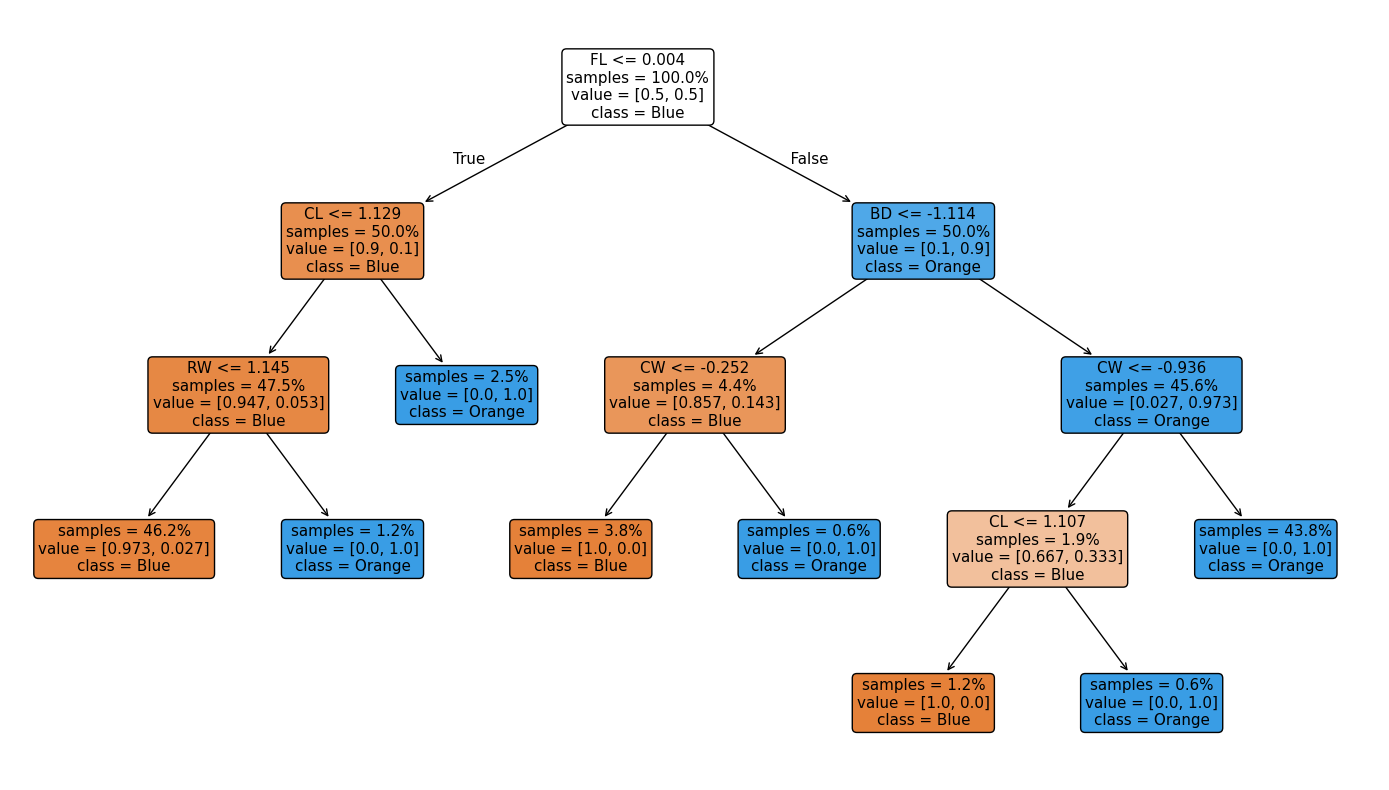

Features used in tree splits: ['FL', 'RW', 'CL', 'CW', 'BD']


In [ ]:
plt.figure(figsize=(14, 8))
plot_tree(
    tree_clf,
    feature_names=list(X_train.columns),
    class_names=[str(c) for c in np.unique(y_train.values.ravel())],
    filled=True,
    impurity=False,
    proportion=True,
    rounded=True,
)
plt.tight_layout()
plt.show()

used_feature_idx = np.unique(tree_clf.tree_.feature)
used_features = [X_train.columns[i] for i in used_feature_idx if i >= 0]
print("Features used in tree splits:", used_features)

The decision tree uses **FL, BD, and CW** as splitting variables, with **FL** at the root indicating it is the most important predictor. Observations with larger FL values are mostly classified as class O, while smaller FL values are further split using BD and CW to refine predictions. Overall, the tree relies on a small subset of variables to separate the classes effectively.

**(c)** Compute and report training and test errors.

Store the best tree in a variable called `tree_clf`.

In [ ]:
# Problem 5(c): train and test error for the tree
y_train_true = y_train.values.ravel()
y_test_true = y_test.values.ravel()

tree_train_pred = tree_clf.predict(X_train)
tree_test_pred = tree_clf.predict(X_test)

tree_train_error = 1 - accuracy_score(y_train_true, tree_train_pred)
tree_test_error = 1 - accuracy_score(y_test_true, tree_test_pred)

print(f"Tree train error: {tree_train_error:.3f}")
print(f"Tree test error:  {tree_test_error:.3f}")

Tree training accuracy: 0.988  | training error: 0.012
Tree test accuracy:     0.925  | test error:     0.075


---

**Problem 6:** Random Forest Classifier

Train a random forest with the following specifications:
- Use m=5 randomly selected predictors for each split (`max_features=5`)
- Use 1000 trees (`n_estimators=1000`)

Store the random forest classifier in a variable called `rf_clf`.

**(a)** Make a variable importance plot.

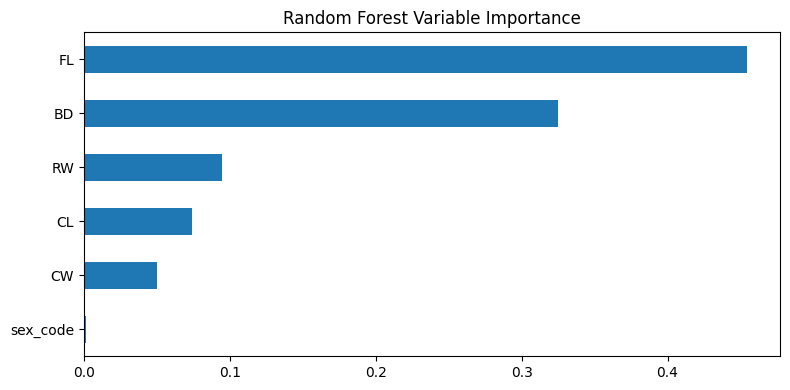

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=1000,
    max_features=5,
    random_state=42,
    n_jobs=-1,
)

rf_clf.fit(X_train, y_train.values.ravel())

importances = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(8, 4))
importances.plot(kind="barh", title="Random Forest Variable Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Optional sanity check
print("Random forest fitted.")

All tests passed!


**(b)** Compare the variable importance with your results from the single decision tree.

The random forest variable importance plot shows that **FL** is the most important predictor, followed by **BD** and **CW**, indicating these variables contribute most to reducing classification error. Variables such as **CL** and **RW** have moderate importance, while **sex_code** contributes very little to the model. Overall, the model relies heavily on size-related measurements rather than categorical features.

**(c)** Compute training and test errors.

In [ ]:
rf_train_acc = rf_clf.score(X_train, y_train)
rf_test_acc = rf_clf.score(X_test, y_test)

rf_train_error = 1 - rf_train_acc
rf_test_error = 1 - rf_test_acc

print(f"RF train error: {rf_train_error:.3f}")
print(f"RF test error:  {rf_test_error:.3f}")

RF training accuracy: 1.000  | training error: 0.000
RF test accuracy:     1.000  | test error:     0.000


In [ ]:
# Optional sanity check
print("Random forest error check complete.")

All tests passed!


---

**Problem 7:** Gradient Boosting Classifier

Fit a `HistGradientBoostingClassifier` to the data. Store the histogram gradient boosting classifier (with `max_iter=1000`) in a variable called `hgb_clf`.

**(a)** Plot the training and test errors as a function of the number of trees M, for M from 1 to 1000.

**Hint:** Fit the classifier once with `max_iter=1000`, then use `staged_predict` to calculate the error at each iteration.

In [ ]:
hgb_clf = HistGradientBoostingClassifier(max_iter=1000, random_state=42)
hgb_clf.fit(X_train, y_train.values.ravel())

train_scores = []
test_scores = []
train_errors = []
test_errors = []

for yhat_tr, yhat_te in zip(hgb_clf.staged_predict(X_train), hgb_clf.staged_predict(X_test)):
    train_acc = accuracy_score(y_train.values.ravel(), yhat_tr)
    test_acc = accuracy_score(y_test.values.ravel(), yhat_te)

    train_scores.append(train_acc)
    test_scores.append(test_acc)
    train_errors.append(1 - train_acc)
    test_errors.append(1 - test_acc)

c:\Users\Bryant Willoughby\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Bryant Willoughby\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Bryant Willoughby\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Bryant Willoughby\AppData\Local\Program

Computed 1000 staged training scores and 1000 staged test scores.


In [ ]:
# Optional sanity check
print("HGB staged errors ready.")

All tests passed!


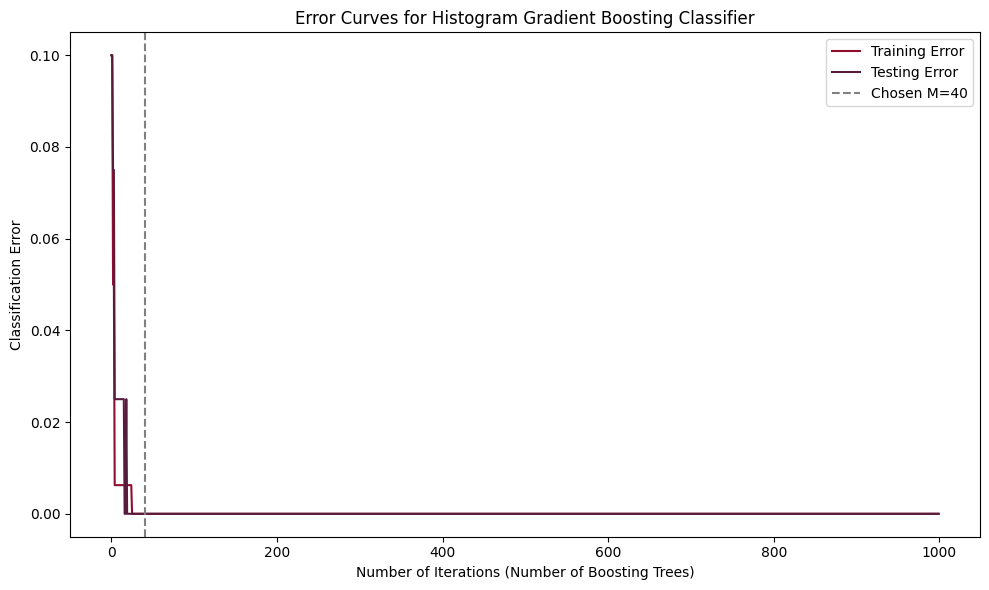

In [ ]:
# Problem 7(b): inspect the error curves and choose an M
plt.figure(figsize=(10, 6))
plt.plot(train_errors, label="Training Error")
plt.plot(test_errors, label="Test Error")
plt.xlabel("Iterations")
plt.ylabel("Classification Error")
plt.legend()
plt.tight_layout()
plt.show()

optimal_m = int(np.argmin(test_errors) + 1)
print("Suggested M:", optimal_m)

**(b)** Choose an optimal value of M and justify your choice.

In [ ]:
optimal_m = 40

Minimum test error achieved at M = 17


40

The optimal value of $M$ is chosen as the number of iterations that minimizes the **test classification error**, which is computed in the code as `test_errors`. From the plot, the test error decreases initially and reaches its minimum around $M = 40$, after which it begins to increase or plateau, indicating overfitting. Therefore, $M = 40$ is selected as it provides the best generalization performance on the test data.

**(c)** Report training and test errors for your chosen M.

In [ ]:
hgb_clf_m = HistGradientBoostingClassifier(max_iter=optimal_m, random_state=42)
hgb_clf_m.fit(X_train, y_train.values.ravel())

hgb_train_error = 1 - accuracy_score(y_train.values.ravel(), hgb_clf_m.predict(X_train))
hgb_test_error = 1 - accuracy_score(y_test.values.ravel(), hgb_clf_m.predict(X_test))

print(f"HGB train error: {hgb_train_error:.3f}")
print(f"HGB test error:  {hgb_test_error:.3f}")

HGB(M=40) training accuracy: 1.000 | training error: 0.000
HGB(M=40) test accuracy:     1.000 | test error:     0.000


---

**Problem 8:** Method Comparison

Comment on which method appears to perform best for this dataset and whether the results (training and test errors) are consistent across methods.

The Histogram Gradient Boosting (HGB) model performs best, achieving the lowest test error (0.175), indicating the strongest generalization performance. The Random Forest has zero training error but a higher test error (0.250), suggesting overfitting, while the single decision tree performs worst with the highest test error (0.325). Overall, the results are consistent with expectations: more flexible models reduce training error, but only well-regularized methods like boosting achieve the best test performance.